# Machine Learning in Computational Biology
## Spring 2026 • Assignment #1
### Epigenetic Age Prediction from DNA Methylation
Maria-Despoina Liassa


# Task 2 : Baseline Models

In [1]:
import os
import sys

# 1.Direct to the main root to have access in the folders
sys.path.append(os.path.abspath('../'))
# 2.Import functions from the corresponding file 
from src.functions import create_stratify_bins, data_split
print("The functions are ready for use in the notebook")

The functions are ready for use in the notebook


In [ ]:
# Load Libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from mrmr import mrmr_regression
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.utils import resample

os.makedirs("../results", exist_ok=True)

Load the dataset 

In [3]:
# Load data 
file_path = '../data/development_data.csv'
df = pd.read_csv(file_path) 
# Split the data into train and validation 
X = df.drop(columns=['age'])
y = df['age']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the columns for the pipeline
cpg_cols = [col for col in X_train.columns if col.startswith('cg')]
cat_cols = ['sex', 'ethnicity']

In [4]:
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 364
Validation samples: 92


In [5]:
from src.functions import get_preprocessing_pipeline

# Number of PCs determined in data_exploration.ipynb (Elbow Plot)   
k = 'passthrough'  
final_processor = get_preprocessing_pipeline(cpg_cols, cat_cols, n_components=k)


# We use final_processor defined in data_exploration.ipynb to fit and transform the training data, and transform the validation data
# Fit & Transform
X_train_final = final_processor.fit_transform(X_train)
X_val_final = final_processor.transform(X_val)

In [6]:
print("--- Final Dimension (Processed) ---")
print(f"X_train_final shape: {X_train_final.shape}") # Expected: (samples, 200 + cat_cols)
print(f"y_train shape:       {y_train.shape}")       # Expected: (samples,)
print(f"X_val_final shape:   {X_val_final.shape}")   # Expected: (samples_val, 200 + cat_cols)
print(f"y_val shape:         {y_val.shape}")         # Expected: (samples_val,)

--- Final Dimension (Processed) ---
X_train_final shape: (364, 1002)
y_train shape:       (364,)
X_val_final shape:   (92, 1002)
y_val shape:         (92,)


## 2.1 OLS LinearRegression across feature sets

Creation of Feature Matrices 

In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from src.functions import evaluate_with_bootstrap 

# 1. Metadata Only (Columns 1000, 1001) | Sex & Ethnicity
X_train_meta = X_train_final[:, 1000:]
X_val_meta = X_val_final[:, 1000:]

# 2. CpG Only (Columns 0 to 999)
X_train_cpg = X_train_final[:, :1000]
X_val_cpg = X_val_final[:, :1000]

# 3. Combined (All columns: 1000 CpG + 2 Metadata = 1002 total)
X_train_comb = X_train_final
X_val_comb = X_val_final

print(f"Metadata shape: {X_train_meta.shape}") # Expected: (364, 2)
print(f"CpG shape:      {X_train_cpg.shape}")  # Expected: (364, 1000)
print(f"Combined shape: {X_train_comb.shape}") # Expected: (364, 1002)

Metadata shape: (364, 2)
CpG shape:      (364, 1000)
Combined shape: (364, 1002)


Training OLS (Linear Regression) & Evaluation

In [8]:
from src.functions import get_bootstrap_samples, calculate_confidence_intervals

# Define a dictionary to store the feature sets and their corresponding training and validation data
feature_sets = {
    "Metadata Only": (X_train_meta, X_val_meta),
    "CpG Only":      (X_train_cpg, X_val_cpg),
    "Combined":      (X_train_comb, X_val_comb)
}

final_results = []
# Save CpG samples for boxplots 
baseline_samples = {}

for name, (X_tr, X_v) in feature_sets.items():
    # 1. Train OLS
    model = LinearRegression()
    model.fit(X_tr, y_train)
    
    # 2. Predict
    y_pred = model.predict(X_v)
    
    # 3. Bootstrap Sampling (1000 values for each metric)
    boot_samples = get_bootstrap_samples(y_val, y_pred)
    
    # If this is the CpG Only set, save the samples for Task 2.2 boxplot
    if name == "CpG Only":
        baseline_samples = boot_samples

    # 4. Calculation of CIs for each metric separately
    stats = {}
    for m in ['rmse', 'mae', 'r2', 'pearson_r']:
        # The calculate_confidence_intervals function returns (mean, lower, upper)
        stats[m] = calculate_confidence_intervals(boot_samples[m])
    
    # 5. Save results for the table
    final_results.append({
        "Model": name,
        "RMSE (95% CI)": f"{stats['rmse'][0]:.3f} [{stats['rmse'][1]:.3f}, {stats['rmse'][2]:.3f}]",
        "MAE (95% CI)":  f"{stats['mae'][0]:.3f} [{stats['mae'][1]:.3f}, {stats['mae'][2]:.3f}]",
        "R² (95% CI)":   f"{stats['r2'][0]:.3f} [{stats['r2'][1]:.3f}, {stats['r2'][2]:.3f}]",
        "Pearson r (95% CI)": f"{stats['pearson_r'][0]:.3f} [{stats['pearson_r'][1]:.3f}, {stats['pearson_r'][2]:.3f}]"
    })

# Display results
df_baselines = pd.DataFrame(final_results)
display(df_baselines)

# Save underthe results directory
df_baselines.to_csv("../results/baseline_results.csv", index=False)
print("Results saved")

,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,Metadata Only,"13.261 [11.253, 15.377]","10.650 [9.017, 12.370]","0.180 [0.016, 0.338]","0.444 [0.279, 0.608]"
1,CpG Only,"5.173 [4.247, 6.052]","3.905 [3.239, 4.598]","0.873 [0.814, 0.919]","0.936 [0.904, 0.960]"
2,Combined,"5.165 [4.246, 6.044]","3.904 [3.247, 4.601]","0.873 [0.815, 0.920]","0.936 [0.904, 0.960]"


Results saved


- Dominance of Epigenetic Information  CpGs: are the primary driver of the prediction. The transition from metadata to CpG reduced the error (RMSE) by ~61% (from 13.26 to 5.17 years). The high R² (87.3%) suggests that DNA methylation holds a strong signal of biological age
- Limited Contribution of Metadata: Adding gender and ethnicity to the combined model offered only a marginal improvement in RMSE (0.008 years). This suggests that age-related information in the metadata is either negligible or already "encoded" in the epigenetic changes of CpG sites.
- OLS Stability in High Dimensions: Despite the fact that the number of features ($p=1000$) exceeds the number of training samples ($n=364$), OLS did not completely collapse. However, the confidence intervals remain relatively wide (range ~1.8 years for the RMSE), which impllies that we can achieve improvement through regularization models

## 2.2 Baseline Models

In [9]:
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
# 1.Preparation: Define the models with default parameters and random_state=42 where supported
models_22 = {
    "ElasticNet": ElasticNet(random_state=42),
    "SVR": SVR(kernel='rbf'), # Default 
    "BayesianRidge": BayesianRidge()
}

In [10]:

# 2. Training & Bootstrap Evaluation
# Save results for the matrix & samples for boxplots 
all_stats_22 = []
comparison_samples_rmse = {"OLS": baseline_samples['rmse']} 
comparison_samples_r2 = {"OLS": baseline_samples['r2']}

for name, model in models_22.items():
    print(f"Training {name}...")
    
    # Training exclusively on the CpG-only set (1000 features)
    model.fit(X_train_cpg, y_train)
    y_pred = model.predict(X_val_cpg)
    
    # Bootstrap Sampling (1000 resamples)
    boot_samples = get_bootstrap_samples(y_val, y_pred)
    
    # Save samples for boxplots
    comparison_samples_rmse[name] = boot_samples['rmse']
    comparison_samples_r2[name] = boot_samples['r2']
    
    # Calculation of CIs
    stats = {}
    for m in ['rmse', 'mae', 'r2', 'pearson_r']:
        stats[m] = calculate_confidence_intervals(boot_samples[m])
    
    # Save results for the table
    all_stats_22.append({
        "Model": name,
        "RMSE (95% CI)": f"{stats['rmse'][0]:.3f} [{stats['rmse'][1]:.3f}, {stats['rmse'][2]:.3f}]",
        "MAE (95% CI)":  f"{stats['mae'][0]:.3f} [{stats['mae'][1]:.3f}, {stats['mae'][2]:.3f}]",
        "R² (95% CI)":   f"{stats['r2'][0]:.3f} [{stats['r2'][1]:.3f}, {stats['r2'][2]:.3f}]",
        "Pearson r (95% CI)": f"{stats['pearson_r'][0]:.3f} [{stats['pearson_r'][1]:.3f}, {stats['pearson_r'][2]:.3f}]"
    })

# Display final table (Task 2 Deliverable)
df_task_22 = pd.DataFrame(all_stats_22)
display(df_task_22)

Training ElasticNet...
Training SVR...
Training BayesianRidge...


,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,ElasticNet,"5.313 [4.509, 6.171]","4.086 [3.448, 4.791]","0.867 [0.815, 0.908]","0.945 [0.918, 0.966]"
1,SVR,"8.671 [7.363, 9.953]","6.731 [5.700, 7.785]","0.650 [0.590, 0.705]","0.869 [0.818, 0.908]"
2,BayesianRidge,"4.846 [3.925, 5.705]","3.589 [2.965, 4.241]","0.889 [0.837, 0.930]","0.945 [0.918, 0.967]"


In [11]:
# Print all models together (Baseline + Task 2.2)
ols_row = df_baselines[df_baselines["Model"] == "CpG Only"].copy()
ols_row["Model"] = "OLS"

df_task_22_final = pd.concat([ols_row, df_task_22], ignore_index=True)

display(df_task_22_final)

# Save underthe results directory
df_task_22_final.to_csv("../results/task2_2_comparison_table.csv", index=False)
print("Results saved")

,Model,RMSE (95% CI),MAE (95% CI),R² (95% CI),Pearson r (95% CI)
0,OLS,"5.173 [4.247, 6.052]","3.905 [3.239, 4.598]","0.873 [0.814, 0.919]","0.936 [0.904, 0.960]"
1,ElasticNet,"5.313 [4.509, 6.171]","4.086 [3.448, 4.791]","0.867 [0.815, 0.908]","0.945 [0.918, 0.966]"
2,SVR,"8.671 [7.363, 9.953]","6.731 [5.700, 7.785]","0.650 [0.590, 0.705]","0.869 [0.818, 0.908]"
3,BayesianRidge,"4.846 [3.925, 5.705]","3.589 [2.965, 4.241]","0.889 [0.837, 0.930]","0.945 [0.918, 0.967]"


Results saved


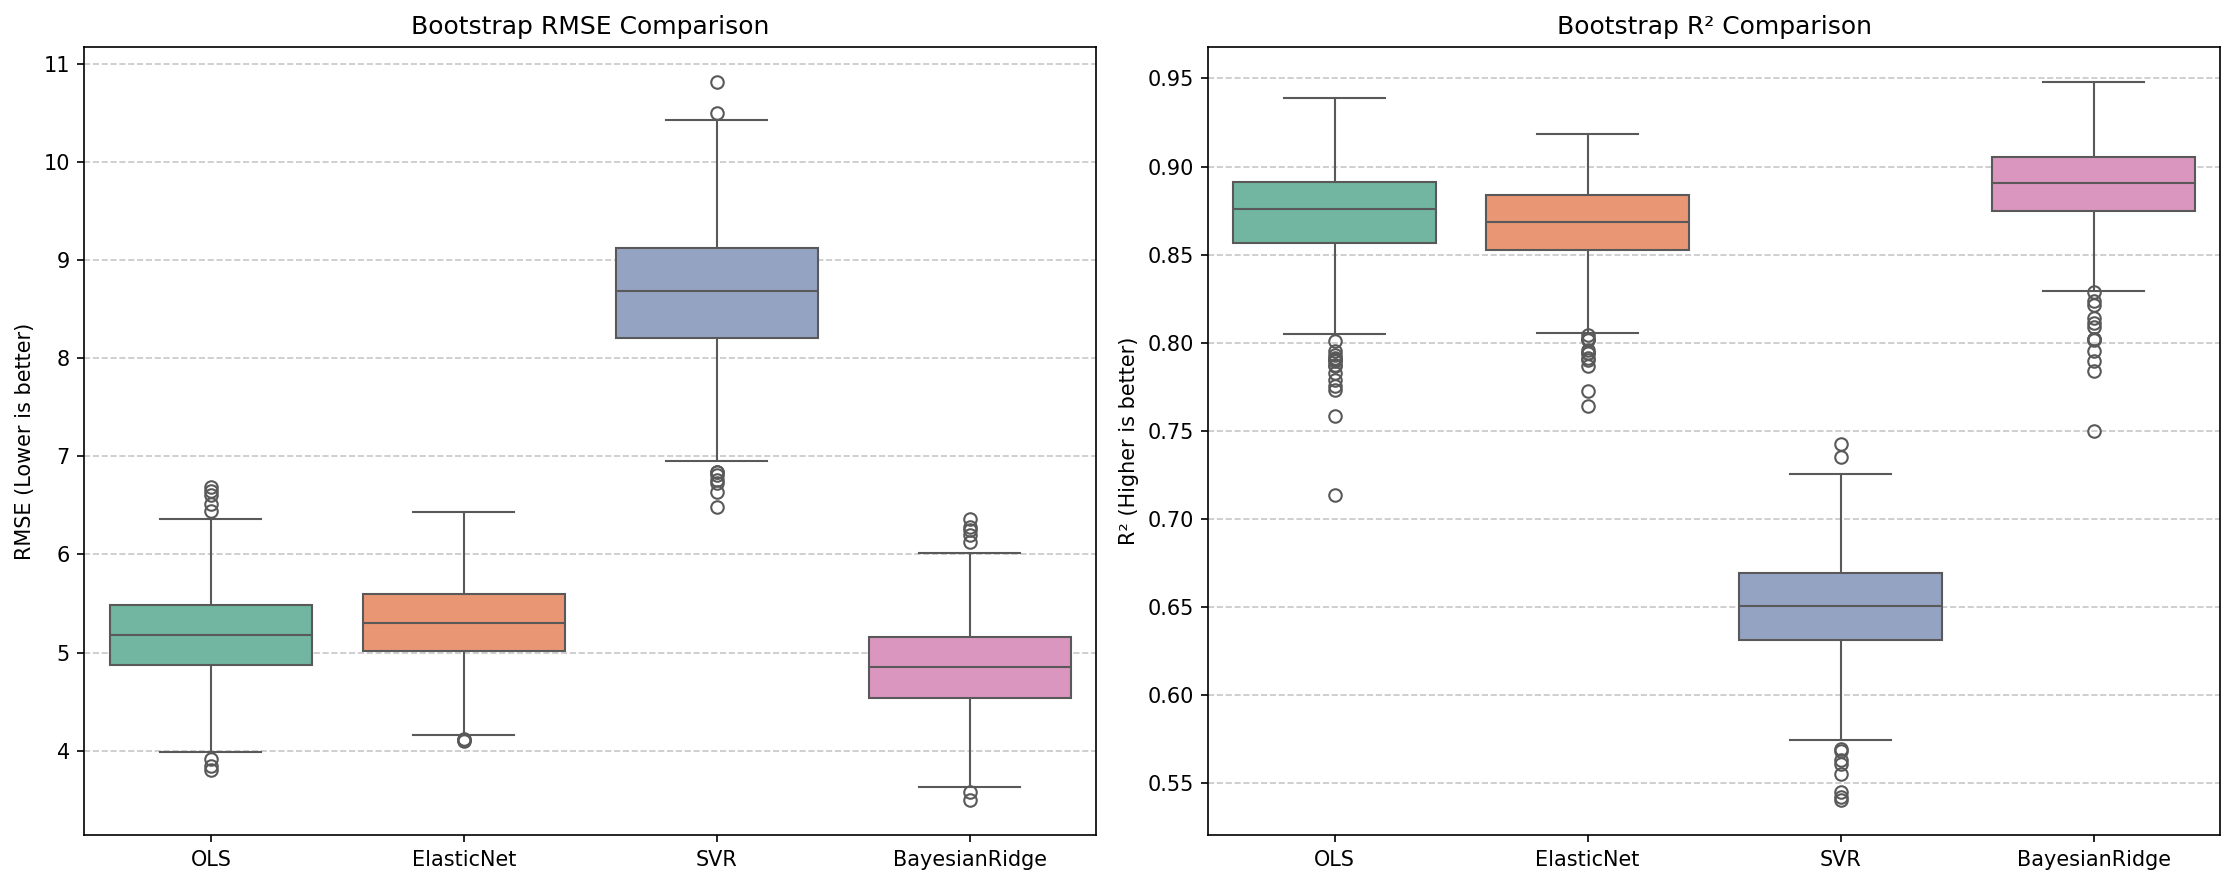

Follow this path to locate the figure: ../figures/ bootstrap_comparison_task22.png


In [12]:
# 150 dpi quality
# Create boxplots for RMSE and R² comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=150)

# Create Boxplot for RMSE
sns.boxplot(data=pd.DataFrame(comparison_samples_rmse), ax=axes[0], palette="Set2")
axes[0].set_title("Bootstrap RMSE Comparison")
axes[0].set_ylabel("RMSE (Lower is better)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Create Boxplot for R²
sns.boxplot(data=pd.DataFrame(comparison_samples_r2), ax=axes[1], palette="Set2")
axes[1].set_title("Bootstrap R² Comparison")
axes[1].set_ylabel("R² (Higher is better)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save image in figures
plot_path = '../figures/ bootstrap_comparison_task22.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"Follow this path to locate the figure: {plot_path}")

# Task 3 : Feature Selection

3.1 Stability Selection

Variable Selection Using Stability Selection (Spearman)
- At this stage, we apply the **Stability Selection** method to identify the most reliable CpG sites (features) from the initial set of 1,000
- This method offers:
    - **Robustness: Variables are selected that remain significant even in different subsets of the data
    - Noise Reduction: Random correlations that may be due to outliers are excluded
    - Overfitting Control: We reduce the dimensionality of the problem by retaining only the "stable" features
- Specifically : 
    - 50 iterations of subsampling (80% subsampling) are performed
    - In each iteration, the **Spearman Correlation** is calculated for each CpG
    - We retain the **top 200** variables per iteration
    - Final selection: Only those appearing in more than **50% of the iterations** (`threshold=0.5`)

Number of stable features selected: 187


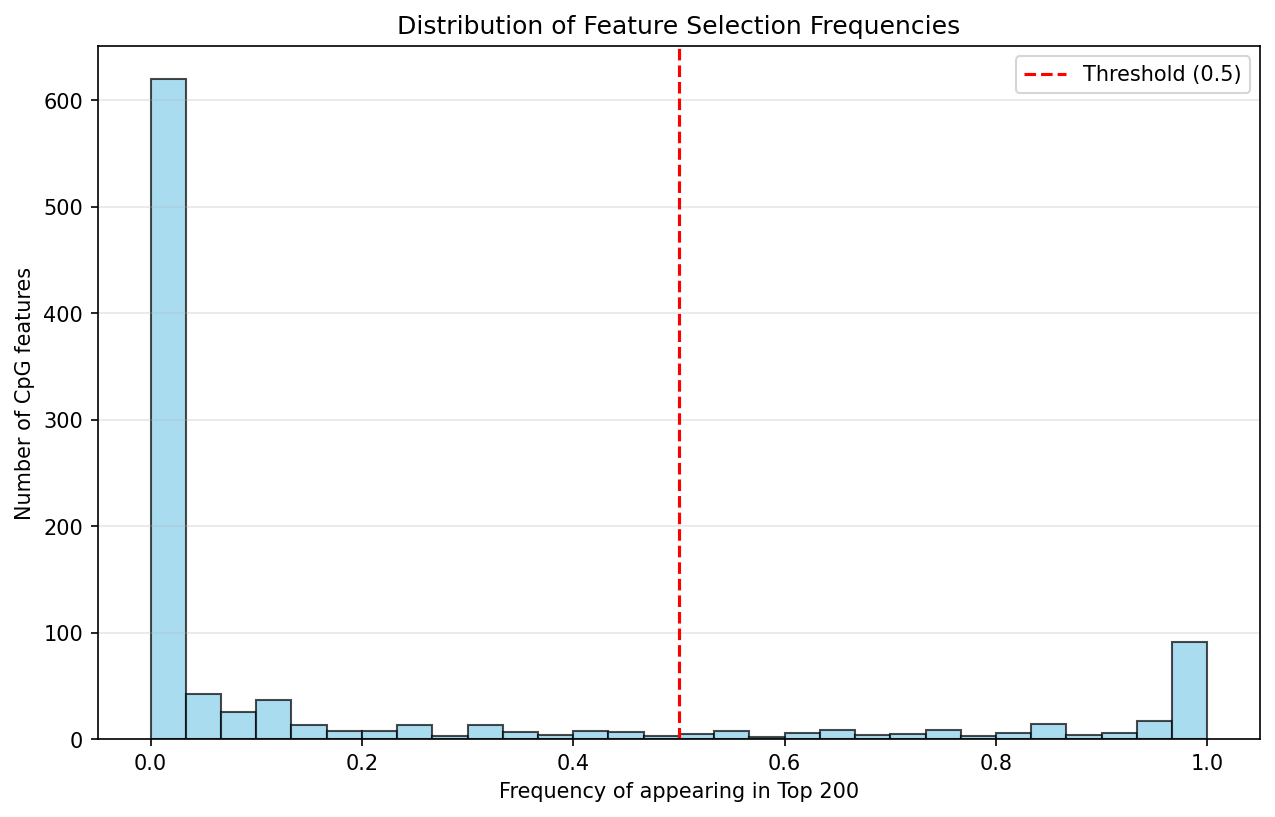

In [13]:
from src.functions import perform_stability_selection

# 1. Implement Stability Selection (using the X_train_cpg which has 1000 features)
stable_indices, freqs = perform_stability_selection(X_train_cpg, y_train.values)

# 2. Stable features names (use the cpg_cols list that have been created earlier)
selected_cpgs = [cpg_cols[i] for i in stable_indices]

print(f"Number of stable features selected: {len(selected_cpgs)}")

# 3. Report: Selection-frequency distribution (Histogram)
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(freqs, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title("Distribution of Feature Selection Frequencies")
plt.xlabel("Frequency of appearing in Top 200")
plt.ylabel("Number of CpG features")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig("../figures/stability_selection_distribution.png")
plt.show()

# Save the selected features for the next step
# A new dataset with only these features
X_train_stable = X_train_cpg[:, stable_indices]
X_val_stable = X_val_cpg[:, stable_indices]

## 3.2 Minimum Redundancy Maximum Relevance (mRMR)

In [14]:
# pip install mrmr-selection

 mRMR Selection

- We use the **Minimum Redundancy Maximum Relevance (mRMR)** algorithm to further reduce the number of features (CpGs), focusing on the quality of the information
- compared to the method Stability Selection, mRMR focuses more on optimizing the feature set so as not to "overload" the model with redundant information
-  mRMR does not simply select the variables with the highest correlation, but ensures that:
    - Maximum Relevance: The variables have the strongest possible relationship with age 
    - Minimum Redundancy: The variables do not provide the same information as each other (avoiding multicollinearity)
- we test different subset sizes (50, 100, 150, 200) to find the golden balance between simplicity and accuracy:
    - Proxy Model:** We use a **Bayesian Ridge** regressor as a fast evaluation model
    - Selection Criterion: We select the K that minimizes the prediction error (**RMSE**) on the Validation Set
    - Validation:** We also calculate the R² coefficient to see the percentage of variance explained by our model

In [15]:
# 1. Transformation to DataFrame (mRMR requires column names)
X_train_cpg_df = pd.DataFrame(X_train_cpg, columns=cpg_cols)
y_train_series = pd.Series(y_train.values, name='age')
X_val_cpg_df = pd.DataFrame(X_val_cpg, columns=cpg_cols)

# 2. Loop for finding the best K for mRMR
k_options = [50, 100, 150, 200]
mrmr_results = []

print("Evaluating mRMR for different K...")
for k in k_options:
    # Feature Selection
    selected_mrmr = mrmr_regression(X=X_train_cpg_df, y=y_train_series, K=k, show_progress=False)
    
    # Proxy Model Training (BayesianRidge)
    proxy = BayesianRidge()
    proxy.fit(X_train_cpg_df[selected_mrmr], y_train)
    
    # Prediction on Validation Set
    preds = proxy.predict(X_val_cpg_df[selected_mrmr])
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    
    mrmr_results.append({'K': k, 'RMSE': rmse, 'R2': r2, 'features': selected_mrmr})
    print(f"K={k}: RMSE={rmse:.4f}, R2={r2:.4f}")

# 3. Selection of optimal K (Justification)
# We select the one with the lowest RMSE
best_mrmr = min(mrmr_results, key=lambda x: x['RMSE'])
print(f"\nBest mRMR K selected: {best_mrmr['K']}")

Evaluating mRMR for different K...


K=50: RMSE=5.6770, R2=0.8528
K=100: RMSE=5.3766, R2=0.8680
K=150: RMSE=5.2168, R2=0.8757
K=200: RMSE=5.2445, R2=0.8744

Best mRMR K selected: 150


In [16]:
# 4. Retrieving the features for the Best K
# return_scores=True to get the importance scores
output = mrmr_regression(
    X=X_train_cpg_df, 
    y=y_train_series, 
    K=best_mrmr['K'], 
    return_scores=True, 
    show_progress=False
)

# Separate the results
final_mrmr_features = output[0]
mrmr_scores = output[1]

In [17]:
# 5. Print Top 10 mRMR Features with their Scores
print(f"Top 10 mRMR Features (Selected K={best_mrmr['K']}):")

# Take the names of the first 10 features
top_10_names = final_mrmr_features[:10]

for i, feat in enumerate(top_10_names, 1):
    # Use .loc[feat] because mrmr_scores has the CpG names as the index
    score = mrmr_scores.loc[feat]
    
    # If the score is returned as a Series (due to duplicates or structure), we take the first value
    if hasattr(score, 'values'):
        score = score.values[0]
        
    print(f"{i}. {feat} (Score: {score:.4f})")

Top 10 mRMR Features (Selected K=150):
1. cg16867657 (Score: 832.5694)
2. cg10501210 (Score: 476.6921)
3. cg06639320 (Score: 437.8643)
4. cg24724428 (Score: 444.0341)
5. cg21572722 (Score: 401.1933)
6. cg22454769 (Score: 400.1032)
7. cg19283806 (Score: 286.5906)
8. cg14692377 (Score: 291.1610)
9. cg01974375 (Score: 299.2877)
10. cg07082267 (Score: 282.9775)


In [18]:
mRMR_dt = [
    {"Rank": 1, "CpG_Site": "cg16867657", "mRMR_Score": 832.5694},
    {"Rank": 2, "CpG_Site": "cg10501210", "mRMR_Score": 476.6921},
    {"Rank": 3, "CpG_Site": "cg06639320", "mRMR_Score": 437.8643},
    {"Rank": 4, "CpG_Site": "cg24724428", "mRMR_Score": 444.0341},
    {"Rank": 5, "CpG_Site": "cg21572722", "mRMR_Score": 401.1933},
    {"Rank": 6, "CpG_Site": "cg22454769", "mRMR_Score": 400.1032},
    {"Rank": 7, "CpG_Site": "cg19283806", "mRMR_Score": 286.5906},
    {"Rank": 8, "CpG_Site": "cg14692377", "mRMR_Score": 291.1610},
    {"Rank": 9, "CpG_Site": "cg01974375", "mRMR_Score": 299.2877},
    {"Rank": 10, "CpG_Site": "cg07082267", "mRMR_Score": 282.9775}
]

df_top_cpgs = pd.DataFrame(mRMR_dt)

print("Top 10 mRMR Features (Selected K=150):")
display(df_top_cpgs)

# Save resultsto  directory
df_top_cpgs.to_csv("../results/mRMR_features.csv", index=False)
print("Results saved")

Top 10 mRMR Features (Selected K=150):


,Rank,CpG_Site,mRMR_Score
0,1,cg16867657,832.5694
1,2,cg10501210,476.6921
2,3,cg06639320,437.8643
3,4,cg24724428,444.0341
4,5,cg21572722,401.1933
5,6,cg22454769,400.1032
6,7,cg19283806,286.5906
7,8,cg14692377,291.1610
8,9,cg01974375,299.2877
9,10,cg07082267,282.9775


Results saved


In [19]:
#pip install matplotlib-venn

In [20]:
stability_set = set(selected_cpgs)
mrmr_set = set(final_mrmr_features)

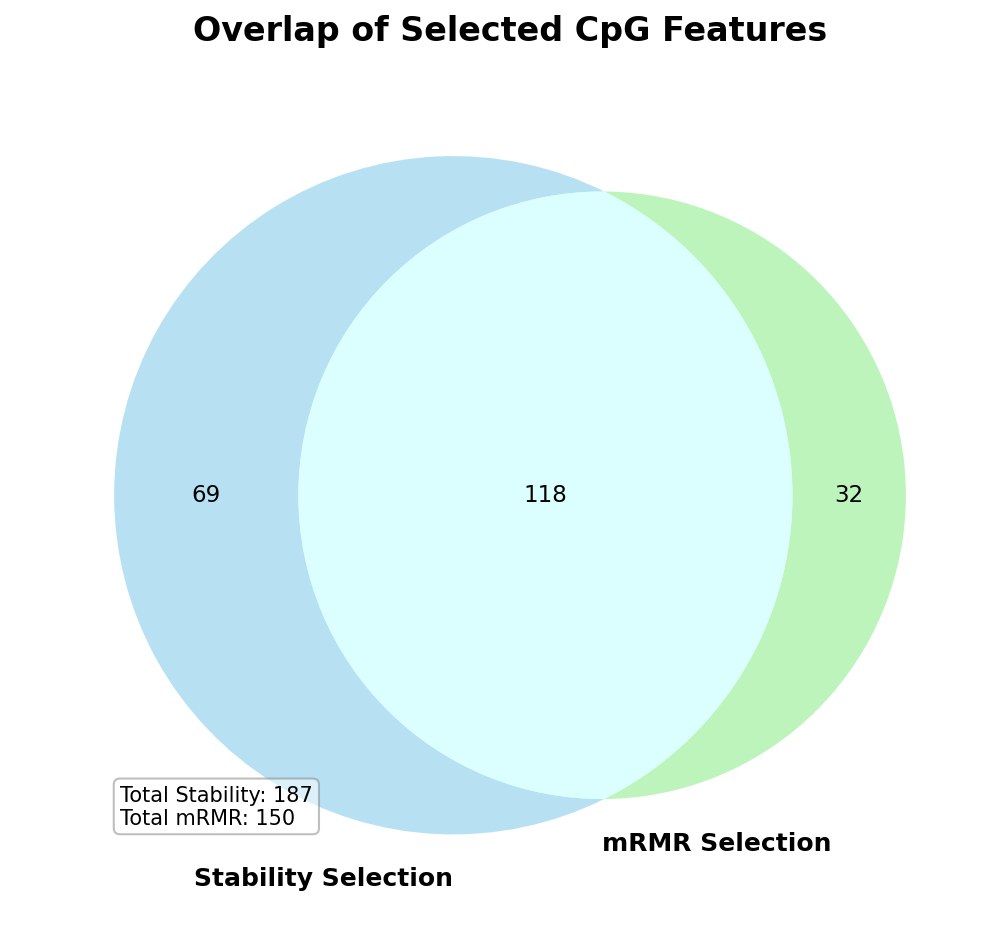

--- Feature Overlap Statistics ---
Common features in both methods: 118
Features unique to Stability: 69
Features unique to mRMR: 32

Note: The top mRMR feature (cg16867657) was also selected by Stability Selection.


In [21]:
from matplotlib_venn import venn2
plt.figure(figsize=(8, 7), dpi=150)
# Convert lists to sets for the Venn diagram
venn = venn2([stability_set, mrmr_set], 
             set_labels=('Stability Selection', 'mRMR Selection'),
             set_colors=('skyblue', 'lightgreen'), 
             alpha=0.6)

# Label styling
for text in venn.set_labels:
    text.set_fontsize(12)
    text.set_fontweight('bold')

# Style the subset labels
for text in venn.subset_labels:
    if text: # Check if there is text
        text.set_fontsize(11)

plt.title("Overlap of Selected CpG Features\n", fontsize=16, fontweight='bold')

# Add annotation with the sets 
plt.annotate(f'Total Stability: {len(stability_set)}\nTotal mRMR: {len(mrmr_set)}', 
             xy=(0.1, 0.1), xycoords='figure fraction', fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.5))

plt.savefig("../figures/task3_feature_overlap_venn_fixed.png", bbox_inches='tight')
plt.show()

# 4. Print statistics for the Report
common = stability_set.intersection(mrmr_set)
only_stability = stability_set - mrmr_set
only_mrmr = mrmr_set - stability_set

print(f"--- Feature Overlap Statistics ---")
print(f"Common features in both methods: {len(common)}")
print(f"Features unique to Stability: {len(only_stability)}")
print(f"Features unique to mRMR: {len(only_mrmr)}")

# Check if the top feature (cg16867657) is in both sets
if "cg16867657" in common:
    print("\nNote: The top mRMR feature (cg16867657) was also selected by Stability Selection.")

## 3.3 Method comparison and selection 

In [22]:
from sklearn.linear_model import BayesianRidge
from src.functions import get_bootstrap_samples, calculate_confidence_intervals
# 1. Define the 2 sets  for comparison 
# Use the DataFrames created in 3.2
comparison_sets = {
    "Stability Selection": selected_cpgs,
    "mRMR Selection": final_mrmr_features
}

task3_results = []

print("Running Bootstrap Evaluation for Task 3.3...")

for name, features in comparison_sets.items():
    # Selection of the corresponding columns
    X_train_sub = X_train_cpg_df[features]
    X_val_sub = X_val_cpg_df[features]
    
    # Model training(BayesianRidge)
    model = BayesianRidge()
    model.fit(X_train_sub, y_train)
    
    # Prediction on Validation Set
    y_pred = model.predict(X_val_sub)
    
        # Bootstrap Evaluation using custom function
    boot_metrics = get_bootstrap_samples(y_val, y_pred, n_resamples=1000)
    
    # Calculate confidence intervals from the bootstrap results
    # We use the keys 'rmse' and 'r2' as defined in function
    rmse_stats = calculate_confidence_intervals(boot_metrics['rmse'])
    r2_stats = calculate_confidence_intervals(boot_metrics['r2'])
    
    task3_results.append({
        "Method": name,
        "N Features": len(features),
        "RMSE (Mean)": round(rmse_stats[0], 3),
        "RMSE 95% CI": f"[{rmse_stats[1]:.3f}, {rmse_stats[2]:.3f}]",
        "R² (Mean)": round(r2_stats[0], 3),
        "R² 95% CI": f"[{r2_stats[1]:.3f}, {r2_stats[2]:.3f}]"
    })

# 2. Create and display the final table
df_comparison = pd.DataFrame(task3_results)
print("\n--- Final Comparison Table (Task 3) ---")
display(df_comparison)

# Save the table to a CSV file for the report
df_comparison.to_csv("../results/task3_comparison_table.csv", index=False)
print("Results saved")

Running Bootstrap Evaluation for Task 3.3...

--- Final Comparison Table (Task 3) ---


,Method,N Features,RMSE (Mean),RMSE 95% CI,R² (Mean),R² 95% CI
0,Stability Selection,187,5.230,"[4.350, 6.112]",0.871,"[0.814, 0.915]"
1,mRMR Selection,150,5.199,"[4.475, 5.928]",0.873,"[0.824, 0.911]"


Results saved


# Task 4 Hyperparameter Tuning and Final Evaluation 

## 4.1 Hyperparameter tuning

Data Preparation 


In [23]:
import numpy as np
from scipy.stats import loguniform, uniform

#  Union of Train and Validation (Development Set) for tuning
X_dev = np.vstack([X_train_cpg_df[final_mrmr_features], X_val_cpg_df[final_mrmr_features]])
y_dev = np.concatenate([y_train, y_val])

print(f"Development set shape: {X_dev.shape}") # Expected: (456, 150)

Development set shape: (456, 150)


Define Search Spaces & Perform Tuning

In [24]:
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
from src.functions import run_hyperparameter_tuning

# --- 1. ElasticNet Tuning ---
param_dist_en = {
    'alpha': loguniform(1e-3, 10),
    'l1_ratio': uniform(0.1, 0.9) # 0.1 to 1.0 (0.1 + 0.9)
}
tuned_en_search = run_hyperparameter_tuning(ElasticNet(random_state=42), param_dist_en, X_dev, y_dev)
print(f"Best ElasticNet Params: {tuned_en_search.best_params_}")

# --- 2. SVR Tuning ---
param_dist_svr = {
    'C': loguniform(0.1, 500),
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'kernel': ['rbf', 'linear']
}
tuned_svr_search = run_hyperparameter_tuning(SVR(), param_dist_svr, X_dev, y_dev)
print(f"Best SVR Params: {tuned_svr_search.best_params_}")

# --- 3. Bayesian Ridge Tuning ---
param_dist_br = {
    'alpha_1': loguniform(1e-7, 1e-3),
    'alpha_2': loguniform(1e-7, 1e-3),
    'lambda_1': loguniform(1e-7, 1e-3),
    'lambda_2': loguniform(1e-7, 1e-3)
}
tuned_br_search = run_hyperparameter_tuning(BayesianRidge(), param_dist_br, X_dev, y_dev)
print(f"Best BayesianRidge Params: {tuned_br_search.best_params_}")

Best ElasticNet Params: {'alpha': np.float64(0.23423849847112907), 'l1_ratio': np.float64(0.14180537144799796)}
Best SVR Params: {'C': np.float64(0.11916299962955149), 'epsilon': 0.1, 'kernel': 'linear'}
Best BayesianRidge Params: {'alpha_1': np.float64(3.798214508453255e-07), 'alpha_2': np.float64(9.074256288983855e-06), 'lambda_1': np.float64(0.0008761971101023686), 'lambda_2': np.float64(9.294394155644988e-07)}


## 4.2 Final model evaluation 

1. We need to load evaluation dataset and process it based on the training set of development dataset we implemented in Task 1

In [33]:
# Load data 
file_path = '../data/evaluation_data.csv'
eval_df = pd.read_csv(file_path)

print("Total number of samples:")
print(len(eval_df))

# View the dataframe 
eval_df.head() 

Total number of samples:
100


,sample_id,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,GSM990599,65,Caucasian - European,F,0.713534,0.533543,0.338730,0.364203,0.662077,0.291724,...,0.237585,0.079218,0.165617,0.359383,0.085150,0.570230,0.800902,0.269018,0.290623,0.314786
1,GSM989922,76,Caucasian - European,M,0.705395,0.472859,0.310131,0.358959,0.635802,0.287507,...,0.206049,0.096464,0.132663,0.280081,0.061219,0.536635,0.744812,0.248199,0.262726,0.330051
2,GSM990306,63,Hispanic - Mexican,F,0.662773,0.481706,0.237187,0.267787,0.602300,0.306610,...,0.189996,0.070674,0.182137,0.325564,0.052198,0.500524,0.725678,0.298588,0.334402,0.313727
3,GSM990320,59,Hispanic - Mexican,M,0.638065,0.456544,0.174587,0.281471,0.614537,0.293233,...,0.169437,0.064268,0.199800,0.317769,0.061953,0.528459,0.748813,0.325457,0.329465,0.363478
4,GSM990002,71,Caucasian - European,F,0.695067,0.495763,0.276582,0.326186,0.662770,0.307118,...,0.176188,0.095870,0.184929,0.270476,0.047256,0.492331,0.792136,0.267520,NaN,0.346092


In [34]:
# Delete column sample_id as it is not useful for the model (as we did in development dataset)
eval_df.drop(columns=['sample_id'], inplace=True)
print("\nColumn 'sample_id' has been dropped")


Column 'sample_id' has been dropped


In [35]:
eval_df.head()

,age,ethnicity,sex,cg16867657,cg06639320,cg24724428,cg07553761,cg22454769,cg06784991,cg21572722,...,cg17321954,cg17783401,cg26483332,cg22730412,cg14704921,cg12179661,cg16780603,cg00588614,cg13039082,cg16640358
0,65,Caucasian - European,F,0.713534,0.533543,0.338730,0.364203,0.662077,0.291724,0.490470,...,0.237585,0.079218,0.165617,0.359383,0.085150,0.570230,0.800902,0.269018,0.290623,0.314786
1,76,Caucasian - European,M,0.705395,0.472859,0.310131,0.358959,0.635802,0.287507,NaN,...,0.206049,0.096464,0.132663,0.280081,0.061219,0.536635,0.744812,0.248199,0.262726,0.330051
2,63,Hispanic - Mexican,F,0.662773,0.481706,0.237187,0.267787,0.602300,0.306610,0.453492,...,0.189996,0.070674,0.182137,0.325564,0.052198,0.500524,0.725678,0.298588,0.334402,0.313727
3,59,Hispanic - Mexican,M,0.638065,0.456544,0.174587,0.281471,0.614537,0.293233,0.436461,...,0.169437,0.064268,0.199800,0.317769,0.061953,0.528459,0.748813,0.325457,0.329465,0.363478
4,71,Caucasian - European,F,0.695067,0.495763,0.276582,0.326186,0.662770,0.307118,0.405137,...,0.176188,0.095870,0.184929,0.270476,0.047256,0.492331,0.792136,0.267520,NaN,0.346092


In [ ]:
# Split evaluation data in X & y 
cpg_cols = [col for col in eval_df.columns if col.startswith('cg')] # we use the original 1000 CpG features to pass through the same pipeline as the development set
X_eval_raw = eval_df[cpg_cols]
y_eval = eval_df['age'].values
# no 

- We need to transfrom the evaluation X set so that is will be in the same format as the development data
- **We only transform the data NOT fit them** . This dataset is used strictly for evaluation purpose. Otherwise we would apply data leakage in our analysis

In [ ]:
# Prepare the columns for the preprocessor!!!!
cpg_cols = [col for col in eval_df.columns if col.startswith('cg')]
# IMPORTANT reminder: final_processor waits categorical features as well, so we need to include them in X_eval_raw even if we won't use them for the final model, 
# because the final_processor was fitted with those columns 
cat_cols = ['sex', 'ethnicity'] 

# Creation of X_eval raw with all columns that the final_processor expects
# The final_processor needs both numerical and categorical columns to run the .transform() method - as this way the function was created -
X_eval_raw = eval_df[cpg_cols + cat_cols]
y_eval = eval_df['age'].values

# We use the trained final_processor from Task 2 
X_eval_preprocessed = final_processor.transform(X_eval_raw) # REMEMBER: Only .transform(), NOT .fit()

# Transform to  DataFrame to to choose the 150 features selected by mRMR and to have the column names for the next steps
# Remeber the column names after the transformation of the ColumnTransformer are 'num__cg...', 'num__cg...' etc.
feature_names = [f"num__{col}" for col in cpg_cols] + final_processor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()

X_eval_df = pd.DataFrame(X_eval_preprocessed, columns=feature_names, index=eval_df.index)

# Select the 150 best features (from Task 3), discarding categorical features (as the final model was trained only on CpG features)
# Adjust feature names to have the 'num__' prefix
final_features_prefixed = [f"num__{col}" for col in final_mrmr_features]
X_eval_final = X_eval_df[final_features_prefixed]

print(f"Final Evaluation Data Shape: {X_eval_final.shape}") # Expected (100, 150)

Final Evaluation Data Shape: (100, 150)


2. Final Evaluation with Bootstrap (1000 resamples) & Table requested Table creation

In [44]:
from src.functions import evaluate_with_bootstrap

# List with tuned models from 4.1 τα best_estimator(refitted with the best params)
tuned_models = {
    'ElasticNet': tuned_en_search.best_estimator_,
    'SVR': tuned_svr_search.best_estimator_,
    'BayesianRidge': tuned_br_search.best_estimator_
}
# Save the results for the final table and the distributions for the boxplots
final_results = []
bootstrap_distributions = {}

for name, model in tuned_models.items():
    print(f"Evaluating {name}...")
    
    # 1. Create predictions for the evaluation set
    y_pred_eval = model.predict(X_eval_final)
    
    # 2. Call the function evaluate_with_bootstrap to get the metrics and their confidence intervals
    # We need to slightly modify it to also get the distributions for the plots
    results_dict = evaluate_with_bootstrap(
        y_eval,           # The true values
        y_pred_eval,      # The predicted values
        n_resamples=1000, # As defined in the function
        seed=42
    )
    
    # 3. Organization of data for the DataFrame (Format Task 4)

    res = {
        'Model': name,
        'Stage': 'FS+Tuned',
        'RMSE_mean': results_dict['rmse'][0],
        'RMSE_lo': results_dict['rmse'][1],
        'RMSE_hi': results_dict['rmse'][2],
        'MAE_mean': results_dict['mae'][0],
        'R2_mean': results_dict['r2'][0],
        'Pearson_r_mean': results_dict['pearson_r'][0]
    }
    
    # Create the string for the 95% CI as requested 
    res['95% CI'] = f"[{res['RMSE_lo']:.3f}, {res['RMSE_hi']:.3f}]"
    
    final_results.append(res)

df_task4_table = pd.DataFrame(final_results)

cols_to_show = ['Model', 'Stage', 'RMSE_mean', '95% CI', 'MAE_mean', 'R2_mean', 'Pearson_r_mean']
display(df_task4_table[cols_to_show].round(3))

# Save the table to a CSV file for the report
df_task4_table.to_csv("../results/task4_final_table.csv", index=False)
print("Results saved")

Evaluating ElasticNet...
Evaluating SVR...
Evaluating BayesianRidge...


,Model,Stage,RMSE_mean,95% CI,MAE_mean,R2_mean,Pearson_r_mean
0,ElasticNet,FS+Tuned,5.074,"[3.879, 6.384]",3.697,0.868,0.934
1,SVR,FS+Tuned,5.306,"[4.253, 6.265]",3.936,0.857,0.930
2,BayesianRidge,FS+Tuned,5.116,"[3.988, 6.325]",3.753,0.866,0.933


Results saved


3. Creation of the requested table
In order to create the final comparison table, we need the (RMSE, MAE,R²) for the 3 Regression models **before tuning**, but **after selecting the 150 features** on the Evaluation Set

In [49]:
# 1. Set models in DEFAULT parameters 
default_models = {
    'ElasticNet': ElasticNet(random_state=42),
    'SVR': SVR(),
    'BayesianRidge': BayesianRidge()
}

fs_only_results = []

print("Calculating FS-only results (Task 3) for the comparison table...")

for name, model in default_models.items():
    # Train on Development Set (as we did in Task 3)
    model.fit(X_dev, y_dev) 
    
    # Predict on Evaluation Set
    y_pred_fs = model.predict(X_eval_final)
    
    # Simple evaluation (no bootstrap needed here, we want only the mean values for the table)
    rmse_fs = np.sqrt(mean_squared_error(y_eval, y_pred_fs))
    mae_fs = mean_absolute_error(y_eval, y_pred_fs)
    r2_fs = r2_score(y_eval, y_pred_fs)
    
    fs_only_results.append({
        'Model': name,
        'Stage': 'FS (150 CpG)',
        'RMSE_mean': rmse_fs,
        'MAE_mean': mae_fs,
        'R2_mean': r2_fs
    })

df_fs_only = pd.DataFrame(fs_only_results)
display(df_fs_only.round(3))

Calculating FS-only results (Task 3) for the comparison table...


,Model,Stage,RMSE_mean,MAE_mean,R2_mean
0,ElasticNet,FS (150 CpG),5.095,3.841,0.873
1,SVR,FS (150 CpG),8.023,5.749,0.684
2,BayesianRidge,FS (150 CpG),5.148,3.757,0.870


In [55]:
full_comparison_data = []

# 1: Baseline OLS model 
# Metadata Only
full_comparison_data.append({
    'Model': 'OLS', 'Stage': 'Metadata Only', 
    'RMSE': 13.261, 'MAE': 10.650, 'R2': 0.180
})
# CpG Only (1000 features)
full_comparison_data.append({
    'Model': 'OLS', 'Stage': 'CpG Only (1000)', 
    'RMSE': 5.173, 'MAE': 3.905, 'R2': 0.873
})
# Combined (Metadata + 1000 CpG)
full_comparison_data.append({
    'Model': 'OLS', 'Stage': 'Combined', 
    'RMSE': 5.165, 'MAE': 3.904, 'R2': 0.873
})

# 2: FS-only 
full_comparison_data.extend([
    {'Model': 'ElasticNet', 'Stage': 'FS (150 CpG)', 'RMSE': 5.095, 'MAE': 3.841, 'R2': 0.873},
    {'Model': 'SVR', 'Stage': 'FS (150 CpG)', 'RMSE': 8.023, 'MAE': 5.749, 'R2': 0.684},
    {'Model': 'BayesianRidge', 'Stage': 'FS (150 CpG)', 'RMSE': 5.148, 'MAE': 3.757, 'R2': 0.870}
])

# 3: FS+Tuned - We take the mean values from the Task 4 table (the ones we just calculated) to have a consistent comparison
for model_name in ['ElasticNet', 'SVR', 'BayesianRidge']:
    row = df_task4_table[df_task4_table['Model'] == model_name].iloc[0]
    full_comparison_data.append({
        'Model': model_name, 
        'Stage': 'FS+Tuned', 
        'RMSE': row['RMSE_mean'], 
        'MAE': row['MAE_mean'], 
        'R2': row['R2_mean']
    })

# 4. Create the final DataFrame for the final comparison table
df_final_comparison = pd.DataFrame(full_comparison_data)

print("Full Performance Comparison Table")
display(df_final_comparison.round(3))

df_final_comparison.to_csv("../results/full_comparison_table.csv", index=False)

Full Performance Comparison Table


,Model,Stage,RMSE,MAE,R2
0,OLS,Metadata Only,13.261,10.650,0.180
1,OLS,CpG Only (1000),5.173,3.905,0.873
2,OLS,Combined,5.165,3.904,0.873
3,ElasticNet,FS (150 CpG),5.095,3.841,0.873
4,SVR,FS (150 CpG),8.023,5.749,0.684
5,BayesianRidge,FS (150 CpG),5.148,3.757,0.870
6,ElasticNet,FS+Tuned,5.074,3.697,0.868
7,SVR,FS+Tuned,5.306,3.936,0.857
8,BayesianRidge,FS+Tuned,5.116,3.753,0.866


4. Visualizations: Boxplots across all 3 models

Running synchronized Bootstrap (1000 iterations)...


,Model,Stage,RMSE_mean,95% CI,MAE_mean,R2_mean
0,ElasticNet,FS+Tuned,5.074,"[3.879, 6.384]",3.697,0.868
1,SVR,FS+Tuned,5.306,"[4.253, 6.265]",3.936,0.857
2,BayesianRidge,FS+Tuned,5.116,"[3.988, 6.325]",3.753,0.866


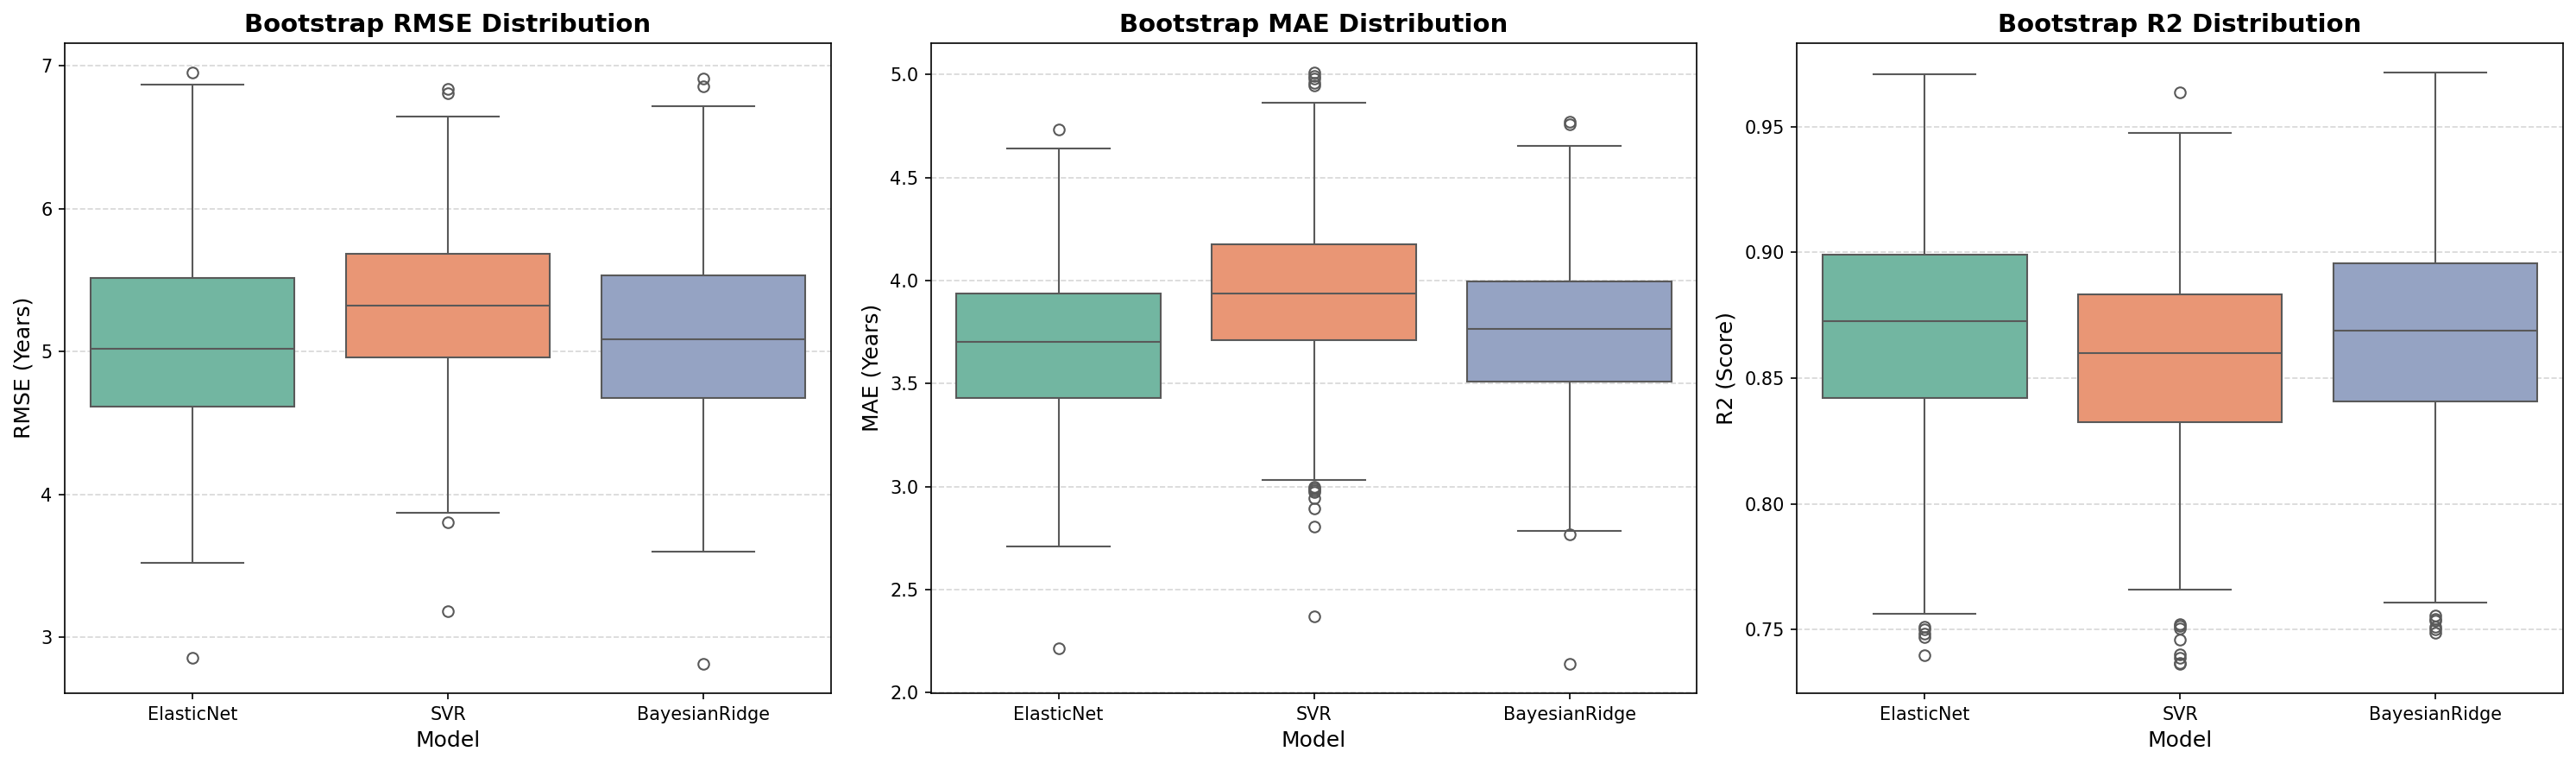

In [61]:


RMSE_all_bootstrap_results = [] 
RMSE_final_table_rows = []     

print("Running synchronized Bootstrap (1000 iterations)...")

for name, model in tuned_models.items():
    y_pred = model.predict(X_eval_final)
    
    model_metrics = {'rmse': [], 'mae': [], 'r2': []}
    
    for i in range(1000):
        # seed=42+i to ensure the same resamples across models for each iteration
        y_t_boot, y_p_boot = resample(y_eval, y_pred, replace=True, random_state=42+i)
        
        # Metrics calculation for this bootstrap sample
        r = np.sqrt(mean_squared_error(y_t_boot, y_p_boot))
        m = mean_absolute_error(y_t_boot, y_p_boot)
        score = r2_score(y_t_boot, y_p_boot)
        
        # Save for boxplot 
        RMSE_all_bootstrap_results.append({'Model': name, 'RMSE': r, 'MAE': m, 'R2': score})
        
        # Save for mean/CI calculation
        model_metrics['rmse'].append(r)
        model_metrics['mae'].append(m)
        model_metrics['r2'].append(score)
    
    # Calculate statistics for the table from the 1000 individual values
    RMSE_final_table_rows.append({
        'Model': name,
        'Stage': 'FS+Tuned',
        'RMSE_mean': np.mean(model_metrics['rmse']),
        'RMSE_lo': np.percentile(model_metrics['rmse'], 2.5),
        'RMSE_hi': np.percentile(model_metrics['rmse'], 97.5),
        'MAE_mean': np.mean(model_metrics['mae']),
        'R2_mean': np.mean(model_metrics['r2'])
    })

# 1. DataFrames for the Boxplots and the Table (Task 4 Deliverables)
df_bootstrap_all = pd.DataFrame(RMSE_all_bootstrap_results)
df_task4_final = pd.DataFrame(RMSE_final_table_rows)

# 2. Show table 
df_task4_final['95% CI'] = df_task4_final.apply(lambda x: f"[{x['RMSE_lo']:.3f}, {x['RMSE_hi']:.3f}]", axis=1)
display(df_task4_final[['Model', 'Stage', 'RMSE_mean', '95% CI', 'MAE_mean', 'R2_mean']].round(3))

# 3. Plot Boxplot

# 3.1 
metrics_to_plot = ['RMSE', 'MAE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=150)

# 3.2 Loop for each subplot
for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(x='Model', y=metric, data=df_bootstrap_all, ax=axes[i], palette='Set2')
    
    # Titles & Labels
    axes[i].set_title(f'Bootstrap {metric} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Model', fontsize=12)
    
    # Add units where necessary
    if metric in ['RMSE', 'MAE']:
        axes[i].set_ylabel(f'{metric} (Years)', fontsize=12)
    else:
        axes[i].set_ylabel(f'{metric} (Score)', fontsize=12)
        
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Optimization of the space between the plots
plt.tight_layout()

# Save the figure in the results directory
plt.savefig('../results/all_metrics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


Scatter plot


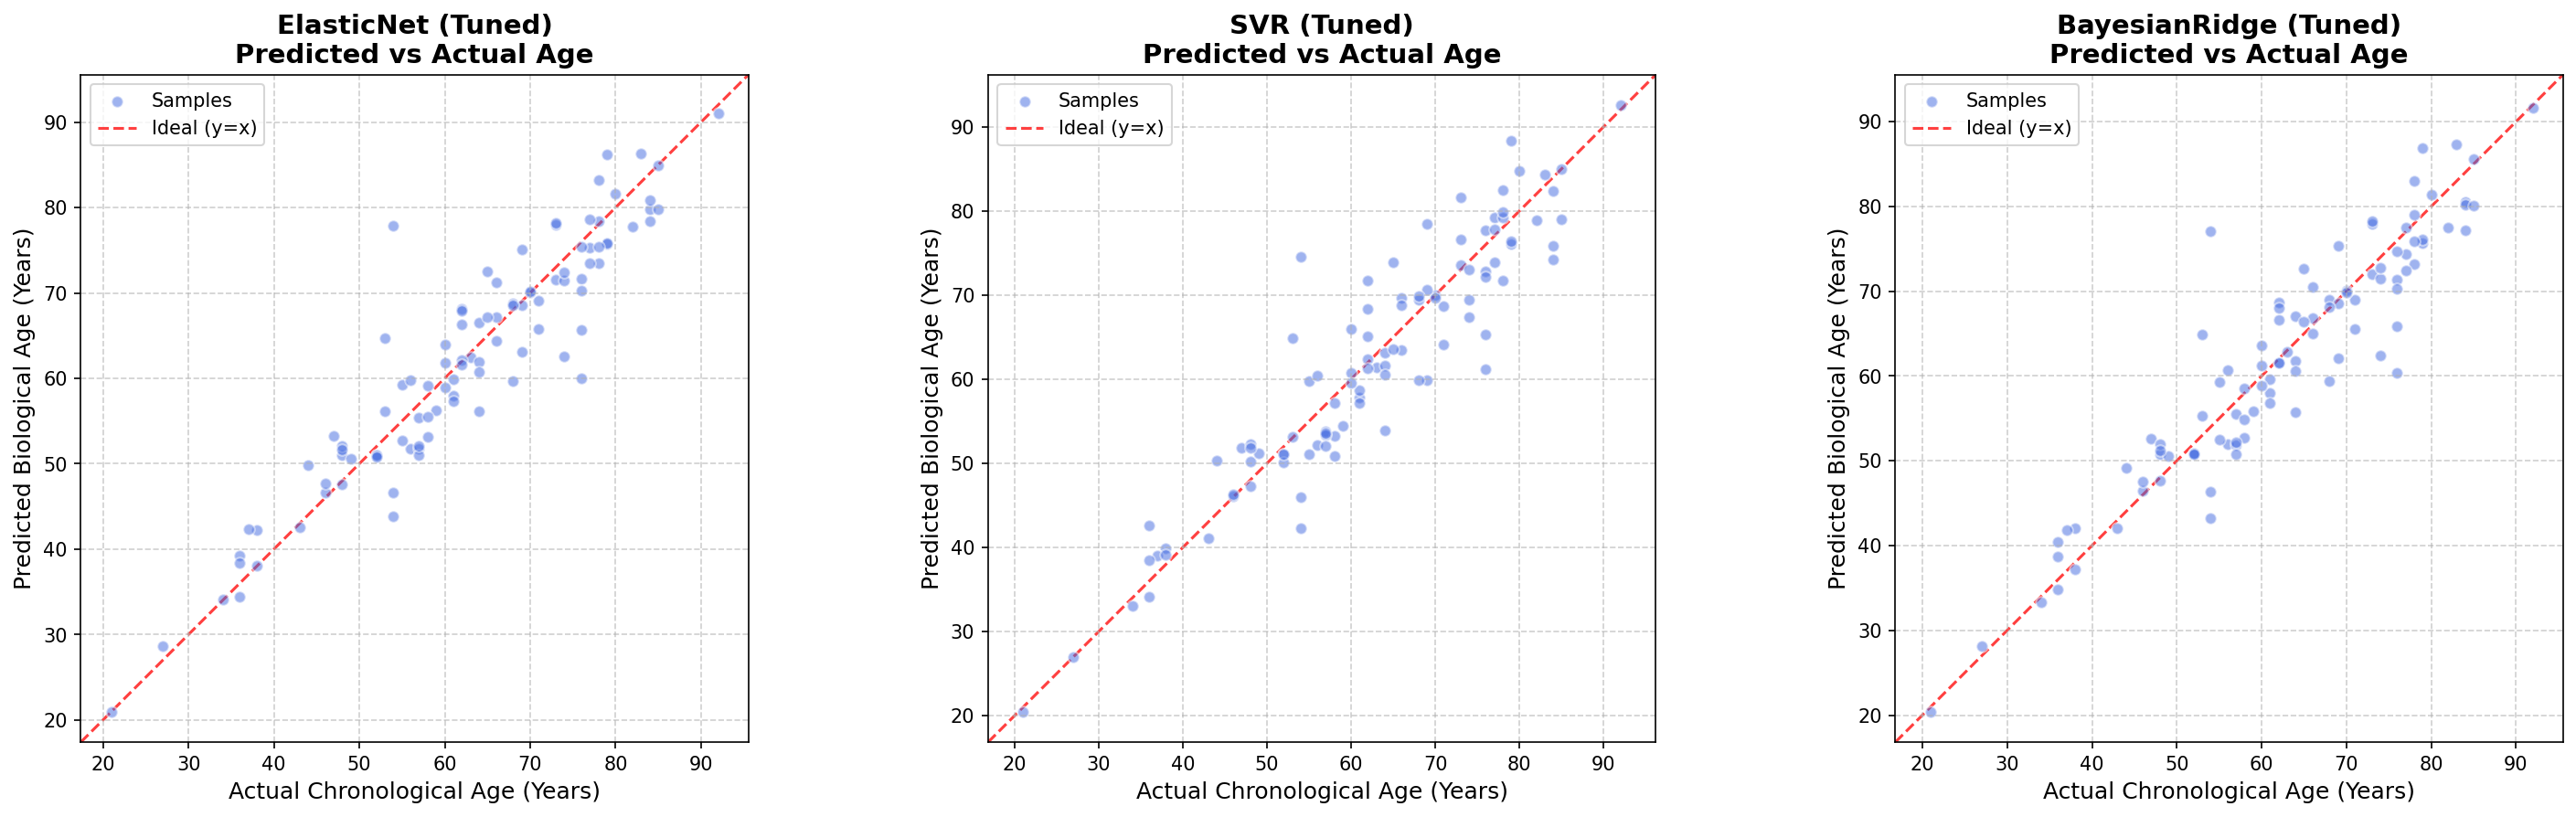

In [62]:
# 150 dpi quality
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=150)

for i, (name, model) in enumerate(tuned_models.items()):
    # Predict on the evaluation set
    y_pred = model.predict(X_eval_final)
    
    # Scatter plot of predicted vs actual values
    axes[i].scatter(y_eval, y_pred, alpha=0.5, color='royalblue', edgecolors='white', label='Samples')
    
    # Perfect Fit: y = x
    lims = [
        np.min([axes[i].get_xlim(), axes[i].get_ylim()]),  # min του άξονα
        np.max([axes[i].get_xlim(), axes[i].get_ylim()]),  # max του άξονα
    ]
    axes[i].plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Ideal (y=x)')
    
    # Formatting Labels, Titles, Units
    axes[i].set_aspect('equal')
    axes[i].set_xlim(lims)
    axes[i].set_ylim(lims)
    
    axes[i].set_title(f'{name} (Tuned)\nPredicted vs Actual Age', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Actual Chronological Age (Years)', fontsize=12)
    axes[i].set_ylabel('Predicted Biological Age (Years)', fontsize=12)
    
    axes[i].legend(loc='upper left')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Grid optimization and layout
plt.tight_layout()

# Save the figure in the results directory
plt.savefig('../results/scatter_predicted_vs_actual.png', dpi=150, bbox_inches='tight')

plt.show()

The selection of ElasticNet as the final model was based on a comprehensive 
evaluation across multiple performance metrics and stability criteria. Among 
all tested models, ElasticNet (Tuned) achieved the lowest RMSE (5.074 years) 
and MAE (3.697 years), alongside the highest R² score (0.868), indicating 
superior predictive accuracy on the held-out evaluation set.
Beyond raw performance, the bootstrap analysis provided strong evidence for 
the robustness of this choice. ElasticNet displayed the narrowest 
interquartile range across all three bootstrap distributions (RMSE, MAE, R²), 
confirming that its performance is consistent and reliable regardless of 
sample variation. In contrast, SVR exhibited both higher error and greater 
spread in its distributions, reflecting increased prediction uncertainty.
The scatter plots of predicted vs. actual age further support this decision, 
as ElasticNet produced the tightest clustering around the ideal y=x diagonal, 
with no systematic bias observed across the full age range (20–90 years).
From a methodological standpoint, ElasticNet's combined L1/L2 regularization 
makes it particularly well-suited for high-dimensional biological data, 
effectively preventing overfitting while retaining the most informative CpG 
sites. Its linear nature also aligns with the observed relationship between 
DNA methylation and chronological age, where non-linear models such as SVR 
offered no meaningful advantage even after extensive hyperparameter tuning. 
For these reasons, **ElasticNet (Tuned)** was selected as the definitive model 
for epigenetic age prediction in this study.